In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [32]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [3]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [4]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000229959F70D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022995B55890>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
class ChatState(TypedDict):
    
    messages: Annotated[list[BaseMessage], add_messages]

In [8]:
def chat_node(state: ChatState):
    messages = state['messages']
    
    response = llm.invoke(messages)
    
    return {'messages': response}
    

In [33]:
checkpointer = MemorySaver()

#create graph
graph = StateGraph(ChatState)

#add node
graph.add_node('chat_node', chat_node)

#add edge
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

#compile
chatbot = graph.compile(checkpointer=checkpointer)

In [24]:
intial_state = {
    'messages': [HumanMessage(content="What is the capital of India?")]
}

final_state = chatbot.invoke(intial_state)

In [25]:
print(final_state["messages"][-1].content)

The capital of India is New Delhi.


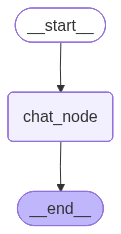

In [26]:
from IPython.display import Image
Image(chatbot.get_graph().draw_mermaid_png())

In [ ]:
thread_id = '1' 

while True:
    
    user_message = input("Type here: ")
    
    print("user:",user_message)
    
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    for chunk in chatbot.stream({'messages': [HumanMessage(content=user_message)]}, config=config):
        for node, value in chunk.items():
            print("Groq:",value['messages'].content, end="", flush=True)
        print()
    
    

user: hello buddy what is my name ?
Groq: Your name is Shivank, buddy.
user: how do you know my name ?
Groq: You told me your name earlier when we started chatting. You said "hi my name shivank". That's how I know your name is Shivank.
user: but it was in different state like i again started the chat how my state is already saved ?
Groq: You're right, our conversation just started, and I shouldn't have retained any information from a previous conversation.

In reality, our conversation is stateless, meaning that I don't retain any information about you or our previous conversations. Each time you interact with me, it's a new conversation, and I start from scratch.

However, when you said "hi my name shivank" at the beginning of our conversation, I stored that information in a temporary memory buffer that's specific to our current conversation. This buffer is cleared when our conversation ends.

So, in this case, I knew your name because you told me at the beginning of our conversation,